# Analisis Kondisi Kendaraan Dinas Menggunakan Algoritma Decision Tree (C4.5)
**Studi Kasus:** Data Kendaraan Kabupaten Sumedang  
**Metode:** Classification (Decision Tree C4.5 / Entropy)

In [22]:
# Import Library
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from IPython.display import display, Markdown, HTML

# Konfigurasi Tampilan & Menyembunyikan Warnings agar Notebook Bersih
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✅ Lingkungan dan library berhasil dimuat.")

✅ Lingkungan dan library berhasil dimuat.


## 1. Pemuatan dan Pembersihan Data (Data Cleaning)
Tahap ini mencakup pemuatan data mentah, penanganan *missing values*, konversi tipe data, serta penyaringan data sesuai dengan ruang lingkup analisis.

In [24]:
# 1. Pemuatan Data
df_raw = pd.read_excel('Data Kendaraan Kabupaten Sumedanglagiii.xlsx', header=None)
df = df_raw.iloc[3:].copy()
display(df)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
3,1,1.3.2.02.01.04.0\n01.,Sepeda Motor,44,Suzuki - AX,100,besi,1987,-,MHJ37P100 9K8936,JBAIE8878,D 110 G,-,Hibah,Rusak Berat,4500000,Ade Kartiwa (Pensiunan),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,1.3.2.02.01.04.0\n01.,Sepeda Motor,20,Honda - Win,100,Besi,1989,NaN,HA145-3580 1,HAE2035786,D 2428 U,NaN,Pembelian,Rusak Ringan,2000000,Pemegang : Agus Setiyana (Pensiunan Bid SDA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3,1.3.2.02.01.04.0\n01.,Sepeda Motor,55,HONDA - WIN,NaN,Various,1989,NaN,NaN,NaN,Z 2883 A,NaN,Pembelian,Rusak Berat,3100000,Pemegang RUSMAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4,1.3.2.02.01.04.0\n01.,Sepeda Motor,98,HONDA - WIN,NaN,Various,1989,NaN,NaN,NaN,Z 2039 A,NaN,Pembelian,Rusak Berat,3100000,Pemegang ENDI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5,1.3.2.02.01.04.0\n01.,Sepeda Motor,112,HONDA - WIN,NaN,Various,1989,NaN,NaN,NaN,Z 3650 A,NaN,Pembelian,Rusak Berat,3100000,Pemegang CECEP JUANDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3749,3747,1.3.2.02.01.01.0\n02.,Jeep,13,Mitsubishi - Pajero Sport 2.4 Dakar (4x2),2500,Besi,2019,-,MK2KRWP NUKJ00100 6,4N15UDL143\n4,Z 1559 A,-,Pembelian,Baik,509087810,PP dengan Pengadilan Negeri Sumedang,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3750,3748,1.3.2.02.01.01.0\n02.,Jeep,19,Mitsubishi - Pajero Sport 2.4 Dakkar,2442,BESI,2019,-,MK2KRWP NUKJ00103 2,4N15UDL211\n4,Z 6 B,P 00906880,Pembelian,Baik,509752432,"Erwan Setiawan, S (Nopol Asal Z 3 A)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3751,3749,1.3.2.02.01.01.0\n01.,Sedan,3,Toyota - Camry,2494,Besi,2014,-,MR053AK50 E4505940,2ARU133076,Z 1392 A,L-01267213,Pembelian,Baik,531570000,Pj. Sekda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3752,3750,1.3.2.02.01.01.0\n01.,Sedan,1,Toyota - Veloz M/T,-,Besi,2015,-,MHKM1CA4 JFK095073,3SZ DFF2706,Z 537 A,-,Hibah,Baik,180892944,Mutasi Antar SKPD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:


# 2. Standarisasi Nama Kolom
df.columns = [
    'No_Urut', 'Kode_Barang', 'Nama_Barang', 'Nomor_Register', 'Merk_Type',
    'Ukuran_cc', 'Bahan', 'Tahun_Pembelian', 'Pabrik', 'Rangka', 'Mesin',
    'Polisi', 'BPKB', 'Asal_Perolehan', 'Kondisi', 'Harga', 'Keterangan'
] + [f'Extra_{i}' for i in range(len(df.columns) - 17)]
df = df.reset_index(drop=True)

# 3. Pembersihan Data (Cleaning)
df = df.dropna(subset=['Tahun_Pembelian', 'Nama_Barang', 'Harga', 'Asal_Perolehan', 'Kondisi']).copy()
df['Harga'] = pd.to_numeric(df['Harga'].astype(str).str.replace(',', '').str.replace(' ', ''), errors='coerce')
df = df[df['Kondisi'].isin(['Baik', 'Rusak Ringan', 'Rusak Berat'])] # Filter kondisi
df = df.drop_duplicates().reset_index(drop=True)

# Menampilkan Ringkasan Data
display(Markdown(f"**Total Data Bersih:** {len(df)} records"))
display(df.head(5).style.set_caption("Preview Data Setelah Pembersihan").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center')]}
]))

**Total Data Bersih:** 3618 records

,No_Urut,Kode_Barang,Nama_Barang,Nomor_Register,Merk_Type,Ukuran_cc,Bahan,Tahun_Pembelian,Pabrik,Rangka,Mesin,Polisi,BPKB,Asal_Perolehan,Kondisi,Harga,Keterangan,Extra_0,Extra_1,Extra_2,Extra_3,Extra_4,Extra_5,Extra_6,Extra_7,Extra_8,Extra_9,Extra_10,Extra_11,Extra_12,Extra_13
0,1,1.3.2.02.01.04.0 01.,Sepeda Motor,44,Suzuki - AX,100,besi,1987,-,MHJ37P100 9K8936,JBAIE8878,D 110 G,-,Hibah,Rusak Berat,4500000.000000,Ade Kartiwa (Pensiunan),nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,2,1.3.2.02.01.04.0 01.,Sepeda Motor,20,Honda - Win,100,Besi,1989,nan,HA145-3580 1,HAE2035786,D 2428 U,nan,Pembelian,Rusak Ringan,2000000.000000,Pemegang : Agus Setiyana (Pensiunan Bid SDA),nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,3,1.3.2.02.01.04.0 01.,Sepeda Motor,55,HONDA - WIN,nan,Various,1989,nan,nan,nan,Z 2883 A,nan,Pembelian,Rusak Berat,3100000.000000,Pemegang RUSMAN,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,4,1.3.2.02.01.04.0 01.,Sepeda Motor,98,HONDA - WIN,nan,Various,1989,nan,nan,nan,Z 2039 A,nan,Pembelian,Rusak Berat,3100000.000000,Pemegang ENDI,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,5,1.3.2.02.01.04.0 01.,Sepeda Motor,112,HONDA - WIN,nan,Various,1989,nan,nan,nan,Z 3650 A,nan,Pembelian,Rusak Berat,3100000.000000,Pemegang CECEP JUANDA,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


## 2. Rekayasa Fitur (Feature Engineering)
Mengubah variabel numerik dan teks menjadi kategori diskrit untuk kebutuhan algoritma C4.5.

In [26]:
# A. Kategori Usia
df['Usia'] = 2024 - df['Tahun_Pembelian']
df['Kategori_Usia'] = pd.cut(df['Usia'], bins=[-1, 5, 10, 100], labels=['Muda', 'Sedang', 'Tua'])

# B. Kategori Jenis
def kategori_jenis(nama):
    nama_str = str(nama).lower()
    return 'Roda Dua' if any(x in nama_str for x in ['motor', 'bebek', 'matic', 'skutik']) else 'Roda Empat'
df['Kategori_Jenis'] = df['Nama_Barang'].apply(kategori_jenis)

# C. Kategori Harga
df['Kategori_Harga'] = pd.cut(df['Harga'], bins=[-1, 15000000, 50000000, np.inf], labels=['Rendah', 'Sedang', 'Tinggi'])

# D. Kategori Asal Perolehan
def kategori_asal(asal):
    asal_str = str(asal).lower()
    if 'pembelian' in asal_str: return 'Pembelian'
    elif 'hibah' in asal_str: return 'Hibah'
    else: return 'Lainnya'
df['Kategori_Asal'] = df['Asal_Perolehan'].apply(kategori_asal)

# E. Standarisasi Target
df['Kondisi'] = df['Kondisi'].str.strip()

# Menampilkan hasil transformasi
cols_show = ['Tahun_Pembelian', 'Kategori_Usia', 'Nama_Barang', 'Kategori_Jenis', 'Harga', 'Kategori_Harga', 'Asal_Perolehan', 'Kategori_Asal', 'Kondisi']
display(df[cols_show].head(5).style.set_caption("Preview Hasil Feature Engineering").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center')]}
]))

,Tahun_Pembelian,Kategori_Usia,Nama_Barang,Kategori_Jenis,Harga,Kategori_Harga,Asal_Perolehan,Kategori_Asal,Kondisi
0,1987,Tua,Sepeda Motor,Roda Dua,4500000.000000,Rendah,Hibah,Hibah,Rusak Berat
1,1989,Tua,Sepeda Motor,Roda Dua,2000000.000000,Rendah,Pembelian,Pembelian,Rusak Ringan
2,1989,Tua,Sepeda Motor,Roda Dua,3100000.000000,Rendah,Pembelian,Pembelian,Rusak Berat
3,1989,Tua,Sepeda Motor,Roda Dua,3100000.000000,Rendah,Pembelian,Pembelian,Rusak Berat
4,1989,Tua,Sepeda Motor,Roda Dua,3100000.000000,Rendah,Pembelian,Pembelian,Rusak Berat


## 3. Analisis Distribusi Kelas Target
Melihat persebaran data berdasarkan kondisi kendaraan untuk mengecek keseimbangan kelas (*class balance*).

In [27]:
distribusi = df['Kondisi'].value_counts()
persentase = (df['Kondisi'].value_counts(normalize=True) * 100).round(2)

tabel_distribusi = pd.DataFrame({
    'Kondisi Kendaraan': distribusi.index,
    'Jumlah Data': distribusi.values,
    'Persentase (%)': persentase.values
})

display(Markdown("### Distribusi Kelas Target"))
display(tabel_distribusi.style.hide(axis="index").set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]))

### Distribusi Kelas Target

Kondisi Kendaraan,Jumlah Data,Persentase (%)
Baik,2804,77.500000
Rusak Ringan,550,15.200000
Rusak Berat,264,7.300000


## 4. Perhitungan Manual Algoritma C4.5
Menghitung *Entropy*, *Information Gain*, *Split Information*, dan *Gain Ratio* untuk menentukan *Root Node*.

In [28]:
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    return -sum((p/len(target_col)) * np.log2(p/len(target_col)) for p in counts if p > 0)

def calc_gain_ratio(data, split_attribute, target_attribute):
    total_entropy = entropy(data[target_attribute])
    vals, counts = np.unique(data[split_attribute], return_counts=True)

    weighted_entropy = sum((len(data[data[split_attribute] == val])/len(data)) * entropy(data[data[split_attribute] == val][target_attribute]) for val in vals)
    info_gain = total_entropy - weighted_entropy

    split_info = -sum((c/len(data)) * np.log2(c/len(data)) for c in counts if c > 0)
    gain_ratio = info_gain / split_info if split_info != 0 else 0

    return total_entropy, info_gain, split_info, gain_ratio

# Eksekusi Perhitungan
atribut = ['Kategori_Usia', 'Kategori_Jenis', 'Kategori_Harga', 'Kategori_Asal']
target = 'Kondisi'

hasil_c45 = []
for attr in atribut:
    ent, ig, si, gr = calc_gain_ratio(df, attr, target)
    hasil_c45.append({'Atribut': attr.replace('Kategori_', ''), 'Information Gain': ig, 'Split Information': si, 'Gain Ratio': gr})

df_hasil_c45 = pd.DataFrame(hasil_c45)
root_node = df_hasil_c45.loc[df_hasil_c45['Gain Ratio'].idxmax()]

display(Markdown(f"**Entropy Total Dataset:** `{entropy(df[target]):.4f}`"))
display(Markdown("### Perbandingan Information Gain dan Gain Ratio"))
display(df_hasil_c45.style.hide(axis="index").format({"Information Gain": "{:.4f}", "Split Information": "{:.4f}", "Gain Ratio": "{:.4f}"}))
display(Markdown(f"👉 **Root Node Terpilih:** `{root_node['Atribut']}` dengan Gain Ratio tertinggi sebesar **{root_node['Gain Ratio']:.4f}**"))

**Entropy Total Dataset:** `0.9737`

### Perbandingan Information Gain dan Gain Ratio

Atribut,Information Gain,Split Information,Gain Ratio
Usia,0.1405,1.2861,0.1092
Jenis,0.0063,0.5188,0.0122
Harga,0.1162,1.3862,0.0838
Asal,0.0149,0.8287,0.0180


👉 **Root Node Terpilih:** `Usia` dengan Gain Ratio tertinggi sebesar **0.1092**

### Detail Distribusi dan Entropy per Atribut
Berikut adalah penjabaran distribusi data dan nilai entropy untuk setiap kategori pada masing-masing atribut.

In [29]:
def buat_tabel_distribusi(df, atribut, target, urutan):
    data = []
    for val in urutan:
        subset = df[df[atribut] == val]
        if len(subset) > 0:
            counts = subset[target].value_counts()
            row = [val] + [counts.get(t, 0) for t in ['Baik', 'Rusak Ringan', 'Rusak Berat']] + [len(subset), entropy(subset[target])]
            data.append(row)

    # Total Row
    total_counts = df[target].value_counts()
    data.append(['Total'] + [total_counts.get(t, 0) for t in ['Baik', 'Rusak Ringan', 'Rusak Berat']] + [len(df), entropy(df[target])])

    columns = [atribut.replace('Kategori_', ''), 'Baik', 'Rusak Ringan', 'Rusak Berat', 'Jumlah', 'Entropy']
    return pd.DataFrame(data, columns=columns)

urutan_dict = {
    'Kategori_Usia': ['Muda', 'Sedang', 'Tua'],
    'Kategori_Jenis': ['Roda Dua', 'Roda Empat'],
    'Kategori_Harga': ['Rendah', 'Sedang', 'Tinggi'],
    'Kategori_Asal': ['Pembelian', 'Hibah', 'Lainnya']
}

for attr, urutan in urutan_dict.items():
    display(Markdown(f"#### Distribusi Atribut {attr.replace('Kategori_', '')}"))
    tbl = buat_tabel_distribusi(df, attr, 'Kondisi', urutan)
    display(tbl.style.hide(axis="index").format({"Entropy": "{:.4f}"}))

#### Distribusi Atribut Usia

Usia,Baik,Rusak Ringan,Rusak Berat,Jumlah,Entropy
Muda,597,0,0,597,-0.0000
Sedang,660,10,5,675,0.1741
Tua,1547,540,259,2346,1.2349
Total,2804,550,264,3618,0.9737


#### Distribusi Atribut Jenis

Jenis,Baik,Rusak Ringan,Rusak Berat,Jumlah,Entropy
Roda Dua,2436,510,251,3197,1.0095
Roda Empat,368,40,13,421,0.6472
Total,2804,550,264,3618,0.9737


#### Distribusi Atribut Harga

Harga,Baik,Rusak Ringan,Rusak Berat,Jumlah,Entropy
Rendah,1154,468,238,1860,1.3077
Sedang,1259,57,19,1335,0.3613
Tinggi,391,25,7,423,0.4440
Total,2804,550,264,3618,0.9737


#### Distribusi Atribut Asal

Asal,Baik,Rusak Ringan,Rusak Berat,Jumlah,Entropy
Pembelian,2208,368,236,2812,0.9579
Hibah,560,181,25,766,0.9833
Lainnya,36,1,3,40,0.5501
Total,2804,550,264,3618,0.9737


### Detail Perhitungan Split Information
Penjabaran matematis untuk menghitung nilai *Split Information* pada setiap atribut.

In [30]:
def display_split_info(df, nama_kolom, nama_atribut):
    total_data = len(df)
    distribusi = df[nama_kolom].value_counts()
    split_info = 0.0
    rumus_parts = []

    rows = []
    for kategori, jumlah in distribusi.items():
        p = jumlah / total_data
        if p > 0:
            hitungan = p * math.log2(p)
            split_info -= hitungan
            rumus_parts.append(f"({p:.3f} × log₂ {p:.3f})")
            rows.append({'Kategori': kategori, 'Jumlah': jumlah, 'Proporsi (p)': f"{p:.4f}", 'Kontribusi': f"{-hitungan:.4f}"})

    df_detail = pd.DataFrame(rows)
    display(Markdown(f"**Atribut {nama_atribut}**"))
    display(df_detail.style.hide(axis="index"))
    display(Markdown(f"**Rumus:** `- [ {' + '.join(rumus_parts)} ]`"))
    display(Markdown(f"**Hasil Split Information:** `{split_info:.4f}`<br><br>---"))

display_split_info(df, 'Kategori_Usia', 'Usia Kendaraan')
display_split_info(df, 'Kategori_Jenis', 'Jenis Kendaraan')
display_split_info(df, 'Kategori_Harga', 'Harga Kendaraan')
display_split_info(df, 'Kategori_Asal', 'Asal Perolehan')

**Atribut Usia Kendaraan**

Kategori,Jumlah,Proporsi (p),Kontribusi
Tua,2346,0.6484,0.4053
Sedang,675,0.1866,0.4519
Muda,597,0.1650,0.4289


**Rumus:** `- [ (0.648 × log₂ 0.648) + (0.187 × log₂ 0.187) + (0.165 × log₂ 0.165) ]`

**Hasil Split Information:** `1.2861`<br><br>---

**Atribut Jenis Kendaraan**

...

**Hasil Split Information:** `1.3862`<br><br>---

**Atribut Asal Perolehan**

Kategori,Jumlah,Proporsi (p),Kontribusi
Pembelian,2812,0.7772,0.2826
Hibah,766,0.2117,0.4742
Lainnya,40,0.0111,0.0719


**Rumus:** `- [ (0.777 × log₂ 0.777) + (0.212 × log₂ 0.212) + (0.011 × log₂ 0.011) ]`

**Hasil Split Information:** `0.8287`<br><br>---

## 5. Pemodelan Machine Learning (Scikit-Learn)
Membangun model *Decision Tree* menggunakan kriteria *Entropy* untuk mereplikasi pendekatan C4.5, serta melakukan evaluasi performa model.

In [31]:
# Persiapan Data
X = df[['Kategori_Usia', 'Kategori_Jenis', 'Kategori_Harga', 'Kategori_Asal']]
y = df['Kondisi']
X_encoded = pd.get_dummies(X)

# Splitting Data (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Training Model
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

labels = ['Baik', 'Rusak Ringan', 'Rusak Berat']
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Tampilan Evaluasi
display(Markdown("### Confusion Matrix"))
display(pd.DataFrame(cm, index=labels, columns=labels).style.set_caption("Confusion Matrix").hide(axis="index"))

display(Markdown("### Classification Report"))
report = classification_report(y_test, y_pred, labels=labels, output_dict=True)
display(pd.DataFrame(report).transpose().style.format("{:.2f}").hide(axis="index"))

akurasi = accuracy_score(y_test, y_pred) * 100
display(Markdown(f"### Akurasi Model: **{akurasi:.2f}%**"))

### Confusion Matrix

Baik,Rusak Ringan,Rusak Berat
554,0,0
106,0,0
64,0,0


### Classification Report

precision,recall,f1-score,support
0.77,1.00,0.87,554.00
0.00,0.00,0.00,106.00
0.00,0.00,0.00,64.00
0.77,0.77,0.77,0.77
0.26,0.33,0.29,724.00
0.59,0.77,0.66,724.00


### Akurasi Model: **76.52%**

### Visualisasi Pohon Keputusan (Decision Tree)

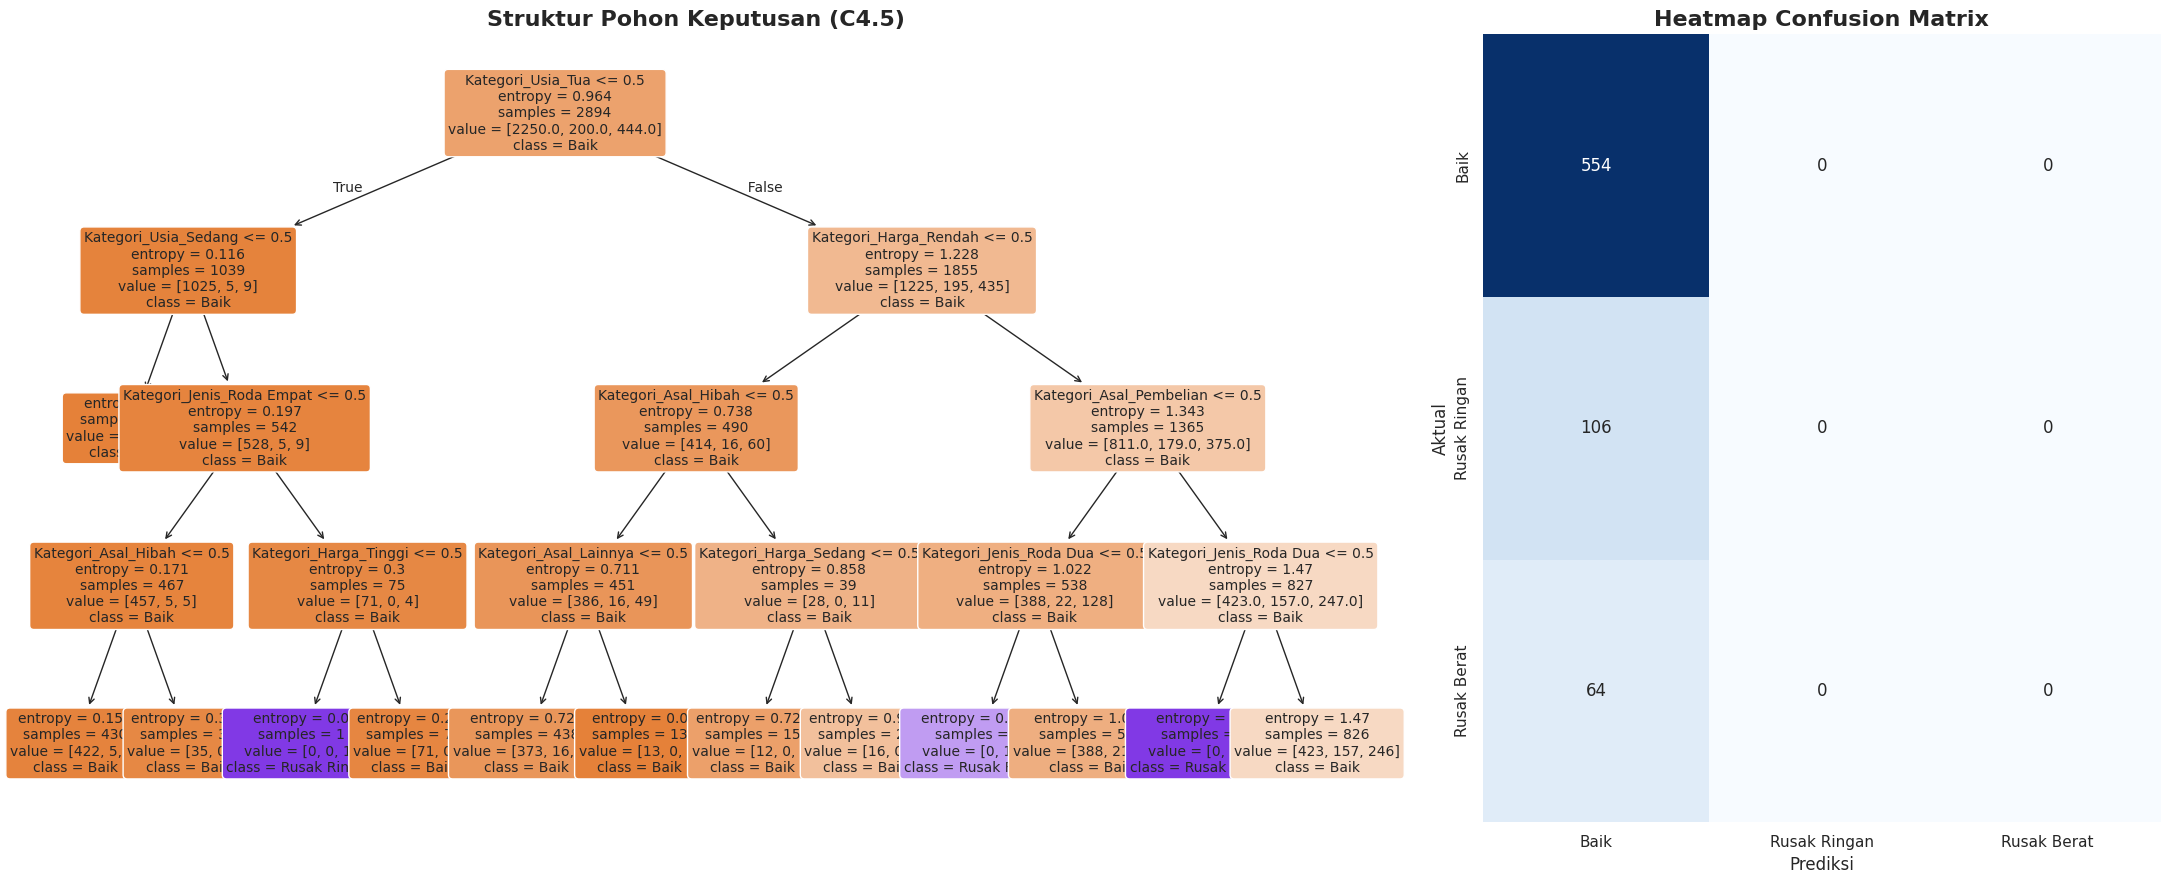

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9), gridspec_kw={'width_ratios': [2, 1]})

# Plot Decision Tree
plot_tree(clf, feature_names=X_encoded.columns, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=10, ax=axes[0])
axes[0].set_title("Struktur Pohon Keputusan (C4.5)", fontsize=16, fontweight='bold')

# Plot Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels, cbar=False)
axes[1].set_xlabel('Prediksi', fontsize=12)
axes[1].set_ylabel('Aktual', fontsize=12)
axes[1].set_title('Heatmap Confusion Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Ekstraksi Aturan Keputusan (IF-THEN Rules)
Menerjemahkan struktur pohon keputusan menjadi aturan logika yang mudah dibaca.

In [35]:
def extract_clean_rules(tree, feature_names, class_names, node=0, conditions=None):
    if conditions is None: conditions = []
    tree_ = tree.tree_
    feature = tree_.feature[node]

    if feature == -2:
        class_distribution = tree_.value[node][0]
        class_idx = np.argmax(class_distribution)
        return [(" AND ".join(conditions) if conditions else "Semua Kondisi",
                 class_names[class_idx],
                 int(class_distribution[class_idx]),
                 (class_distribution[class_idx] / sum(class_distribution)) * 100)]

    feature_name = feature_names[feature]
    parts = feature_name.split('_')
    attr_map = {"Usia": "Usia", "Jenis": "Jenis", "Harga": "Harga", "Asal": "Asal"}
    attr = attr_map.get(parts[1], parts[1]) if len(parts) >= 3 else feature_name
    val = " ".join(parts[2:]) if len(parts) >= 3 else str(tree_.threshold[node])

    rules = []
    rules.extend(extract_clean_rules(tree, feature_names, class_names, tree_.children_left[node], conditions + [f"{attr} = {val}"]))
    rules.extend(extract_clean_rules(tree, feature_names, class_names, tree_.children_right[node], conditions + [f"{attr} Selain {val}"]))
    return rules

clean_rules = extract_clean_rules(clf, X_encoded.columns.tolist(), clf.classes_.tolist())

rules_md = "### Aturan Keputusan (Decision Rules)\n"
for i, (rule, result, support, conf) in enumerate(clean_rules, 1):
    rules_md += f"**Rule {i}:**<br>"
    rules_md += f"👉 **IF** `{rule}`<br>"
    rules_md += f"👉 **THEN** Kondisi Kendaraan = **{result}**<br>"
    rules_md += f"<i>(Support: {support} data | Confidence: {conf:.1f}%)</i><br><br>"

display(Markdown(rules_md))

### Aturan Keputusan (Decision Rules)
**Rule 1:**<br>👉 **IF** `Usia = Tua AND Usia = Sedang`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 1 data | Confidence: 100.0%)</i><br><br>**Rule 2:**<br>👉 **IF** `Usia = Tua AND Usia Selain Sedang AND Jenis = Roda Empat AND Asal = Hibah`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 98.1%)</i><br><br>**Rule 3:**<br>👉 **IF** `Usia = Tua AND Usia Selain Sedang AND Jenis = Roda Empat AND Asal Selain Hibah`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 94.6%)</i><br><br>**Rule 4:**<br>👉 **IF** `Usia = Tua AND Usia Selain Sedang AND Jenis Selain Roda Empat AND Harga = Tinggi`<br>👉 **THEN** Kondisi Kendaraan = **Rusak Ringan**<br><i>(Support: 1 data | Confidence: 100.0%)</i><br><br>**Rule 5:**<br>👉 **IF** `Usia = Tua AND Usia Selain Sedang AND Jenis Selain Roda Empat AND Harga Selain Tinggi`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 95.9%)</i><br><br>**Rule 6:**<br>👉 **IF** `Usia Selain Tua AND Harga = Rendah AND Asal = Hibah AND Asal = Lainnya`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 85.2%)</i><br><br>**Rule 7:**<br>👉 **IF** `Usia Selain Tua AND Harga = Rendah AND Asal = Hibah AND Asal Selain Lainnya`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 1 data | Confidence: 100.0%)</i><br><br>**Rule 8:**<br>👉 **IF** `Usia Selain Tua AND Harga = Rendah AND Asal Selain Hibah AND Harga = Sedang`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 80.0%)</i><br><br>**Rule 9:**<br>👉 **IF** `Usia Selain Tua AND Harga = Rendah AND Asal Selain Hibah AND Harga Selain Sedang`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 66.7%)</i><br><br>**Rule 10:**<br>👉 **IF** `Usia Selain Tua AND Harga Selain Rendah AND Asal = Pembelian AND Jenis = Roda Dua`<br>👉 **THEN** Kondisi Kendaraan = **Rusak Ringan**<br><i>(Support: 0 data | Confidence: 66.7%)</i><br><br>**Rule 11:**<br>👉 **IF** `Usia Selain Tua AND Harga Selain Rendah AND Asal = Pembelian AND Jenis Selain Roda Dua`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 72.5%)</i><br><br>**Rule 12:**<br>👉 **IF** `Usia Selain Tua AND Harga Selain Rendah AND Asal Selain Pembelian AND Jenis = Roda Dua`<br>👉 **THEN** Kondisi Kendaraan = **Rusak Ringan**<br><i>(Support: 1 data | Confidence: 100.0%)</i><br><br>**Rule 13:**<br>👉 **IF** `Usia Selain Tua AND Harga Selain Rendah AND Asal Selain Pembelian AND Jenis Selain Roda Dua`<br>👉 **THEN** Kondisi Kendaraan = **Baik**<br><i>(Support: 0 data | Confidence: 51.2%)</i><br><br>

## 7. Simulasi Prediksi Data Baru
Menguji model dengan skenario data kendaraan baru untuk melihat hasil prediksi kondisi.

In [36]:
def simulasi_kendaraan(usia, jenis, harga, asal):
    data_baru = pd.DataFrame({
        'Kategori_Usia': [usia], 'Kategori_Jenis': [jenis],
        'Kategori_Harga': [harga], 'Kategori_Asal': [asal]
    })

    data_baru_encoded = pd.get_dummies(data_baru).reindex(columns=X_encoded.columns, fill_value=0)
    prediksi = clf.predict(data_baru_encoded)[0]
    probabilitas = clf.predict_proba(data_baru_encoded)[0]

    display(Markdown("### Hasil Simulasi Prediksi"))
    display(pd.DataFrame([{
        'Usia': usia, 'Jenis': jenis, 'Harga': harga, 'Asal': asal
    }]).style.hide(axis="index"))

    display(Markdown(f"🎯 **Prediksi Kondisi:** `{prediksi.upper()}`"))
    display(Markdown(f"📊 **Tingkat Keyakinan (Confidence):** `{max(probabilitas)*100:.2f}%`"))

# Eksekusi Simulasi
simulasi_kendaraan('Tua', 'Roda Dua', 'Rendah', 'Pembelian')

### Hasil Simulasi Prediksi

Usia,Jenis,Harga,Asal
Tua,Roda Dua,Rendah,Pembelian


🎯 **Prediksi Kondisi:** `BAIK`

📊 **Tingkat Keyakinan (Confidence):** `51.21%`